# ReneWind: Predicting Wind-Turbine Generator Failures

### Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).



## Objective
“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description
- The data provided is a transformed version of original data which was collected using sensors.
- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.
- Both the datasets consist of 40 predictor variables and 1 target variable

> **Status:** completed in 2026 from the course template (the original draft only ran the setup and data-loading cells). Every cell runs top to bottom from `data/`.

## Importing libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

sns.set_style('whitegrid')
RS = 1

## Loading the data

In [2]:
train_full = pd.read_csv('data/Train.csv')
test = pd.read_csv('data/Test.csv')
print('Train:', train_full.shape, ' Test:', test.shape)
train_full.head()

Train: (20000, 41)  Test: (5000, 41)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


## Data overview

In [3]:
print('Missing values (train):'); print(train_full.isnull().sum()[lambda s: s > 0])
print('Missing values (test):');  print(test.isnull().sum()[lambda s: s > 0])
print('Duplicates:', train_full.duplicated().sum())
print('\nFailure rate  train: {:.2%}   test: {:.2%}'.format(train_full['Target'].mean(), test['Target'].mean()))

Missing values (train):
V1    18
V2    18
dtype: int64
Missing values (test):
V1    5
V2    6
dtype: int64
Duplicates: 0

Failure rate  train: 5.55%   test: 5.64%


In [4]:
train_full.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.27,3.44,-11.88,-2.74,-0.75,1.84,15.49
V2,19982.0,0.44,3.15,-12.32,-1.64,0.47,2.54,13.09
V3,20000.0,2.48,3.39,-10.71,0.21,2.26,4.57,17.09
V4,20000.0,-0.08,3.43,-15.08,-2.35,-0.14,2.13,13.24
V5,20000.0,-0.05,2.10,-8.60,-1.54,-0.10,1.34,8.13
V6,20000.0,-1.00,2.04,-10.23,-2.35,-1.00,0.38,6.98
V7,20000.0,-0.88,1.76,-7.95,-2.03,-0.92,0.22,8.01
V8,20000.0,-0.55,3.30,-15.66,-2.64,-0.39,1.72,11.68
V9,20000.0,-0.02,2.16,-8.60,-1.49,-0.07,1.41,8.14
V10,20000.0,-0.01,2.19,-9.85,-1.41,0.10,1.48,8.11


**Observations**
- 40 anonymised (ciphered) sensor features, all numeric, so they cannot be interpreted physically.
- A few values are missing in `V1` and `V2`. They are imputed with the median, fitted on training data only.
- Failures are rare (about 5.5%), so accuracy would be misleading: a model that never predicts a failure would be about 94% accurate.

## Exploratory Data Analysis

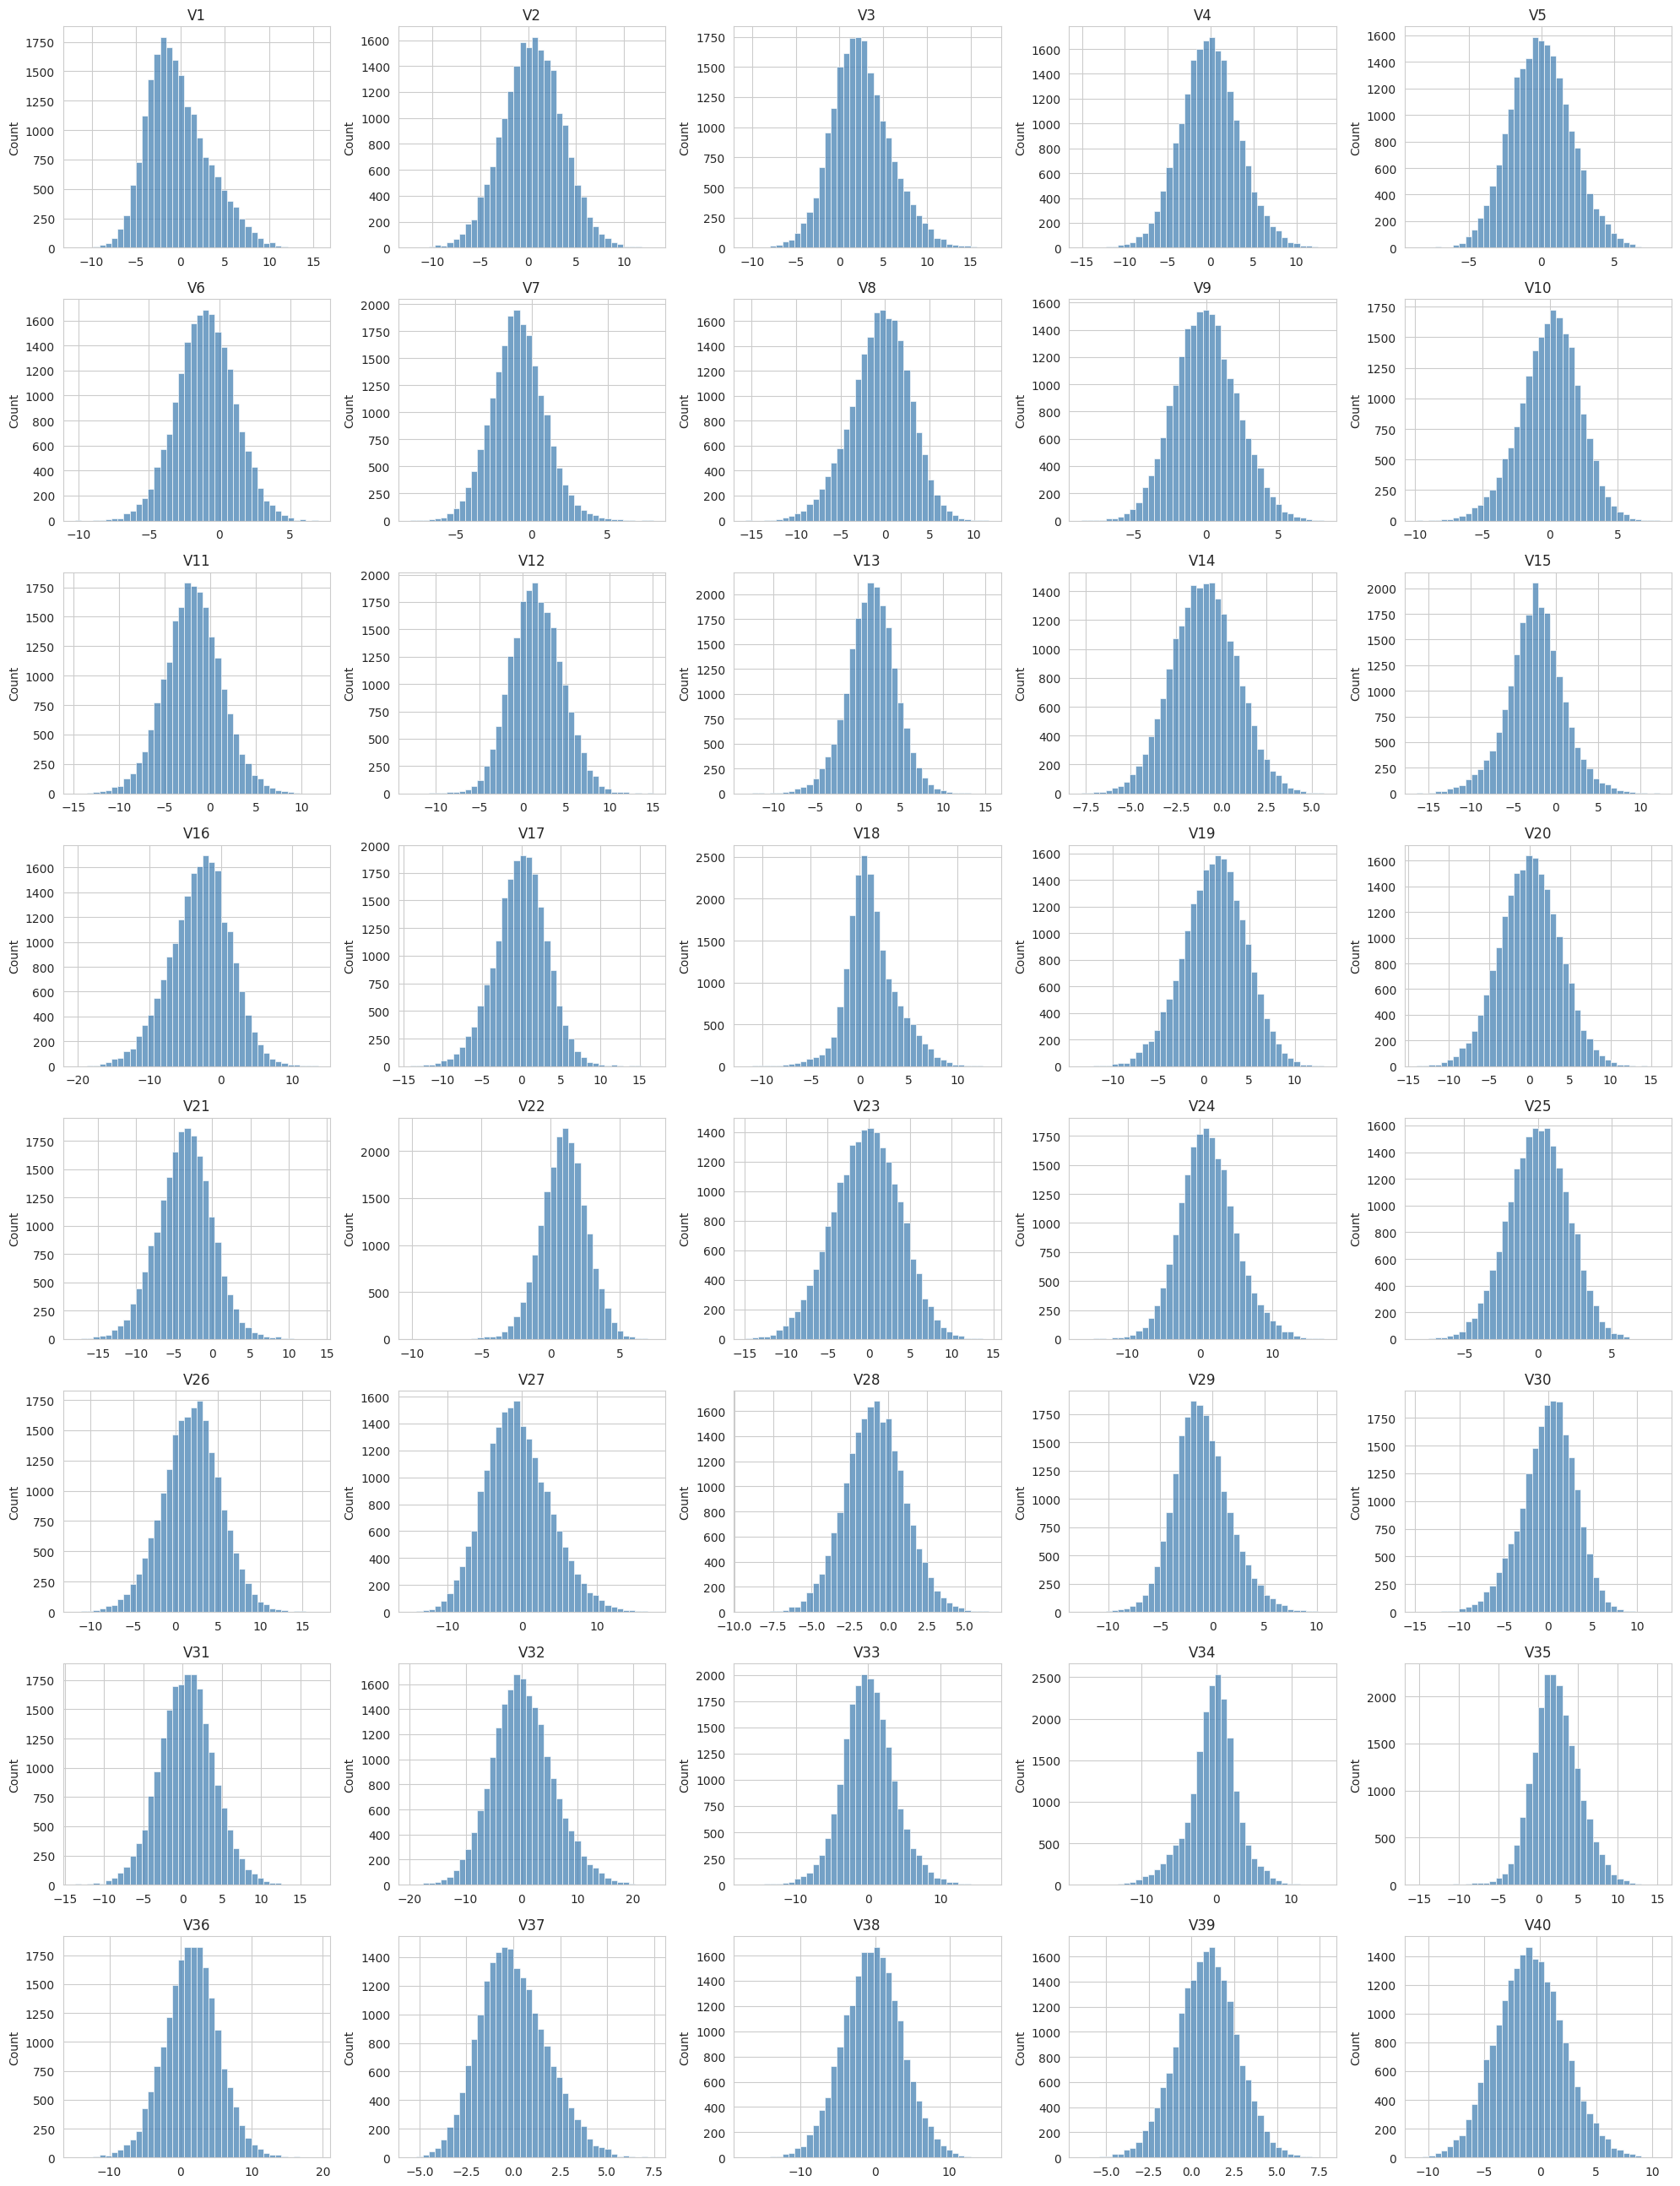

In [5]:
fig, axes = plt.subplots(8, 5, figsize=(20, 26))
for ax, col in zip(axes.flat, train_full.columns[:-1]):
    sns.histplot(train_full[col], ax=ax, bins=40, color='steelblue')
    ax.set_title(col); ax.set_xlabel('')
plt.tight_layout(); plt.show()

In [6]:
# Which sensors separate failures from non-failures most? (difference in means, in standard deviations)
std_diff = ((train_full[train_full.Target == 1].mean() - train_full[train_full.Target == 0].mean())
            / train_full.std()).drop('Target').sort_values(key=abs, ascending=False)
std_diff.head(10).round(2)

V18   -1.28
V21    1.12
V15    1.09
V7     1.03
V16    1.01
V39   -0.99
V36   -0.95
V3    -0.93
V28    0.91
V11    0.86
dtype: float64

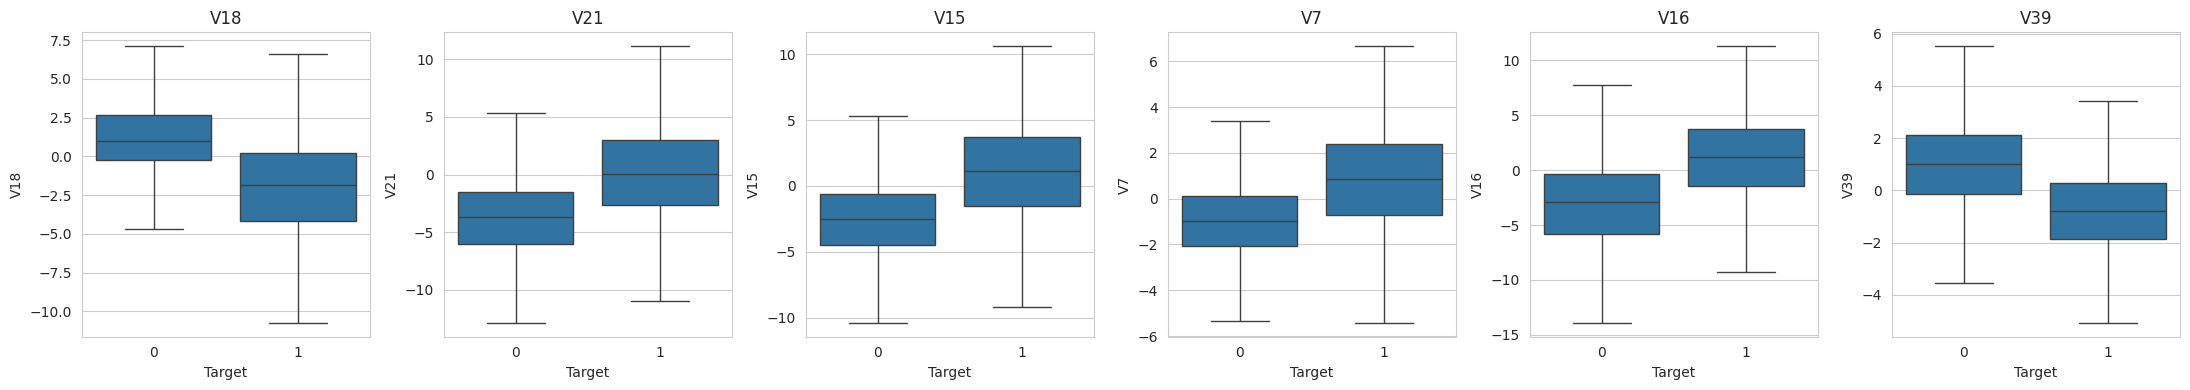

In [7]:
top = std_diff.head(6).index
fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for ax, col in zip(axes, top):
    sns.boxplot(data=train_full, x='Target', y=col, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout(); plt.show()

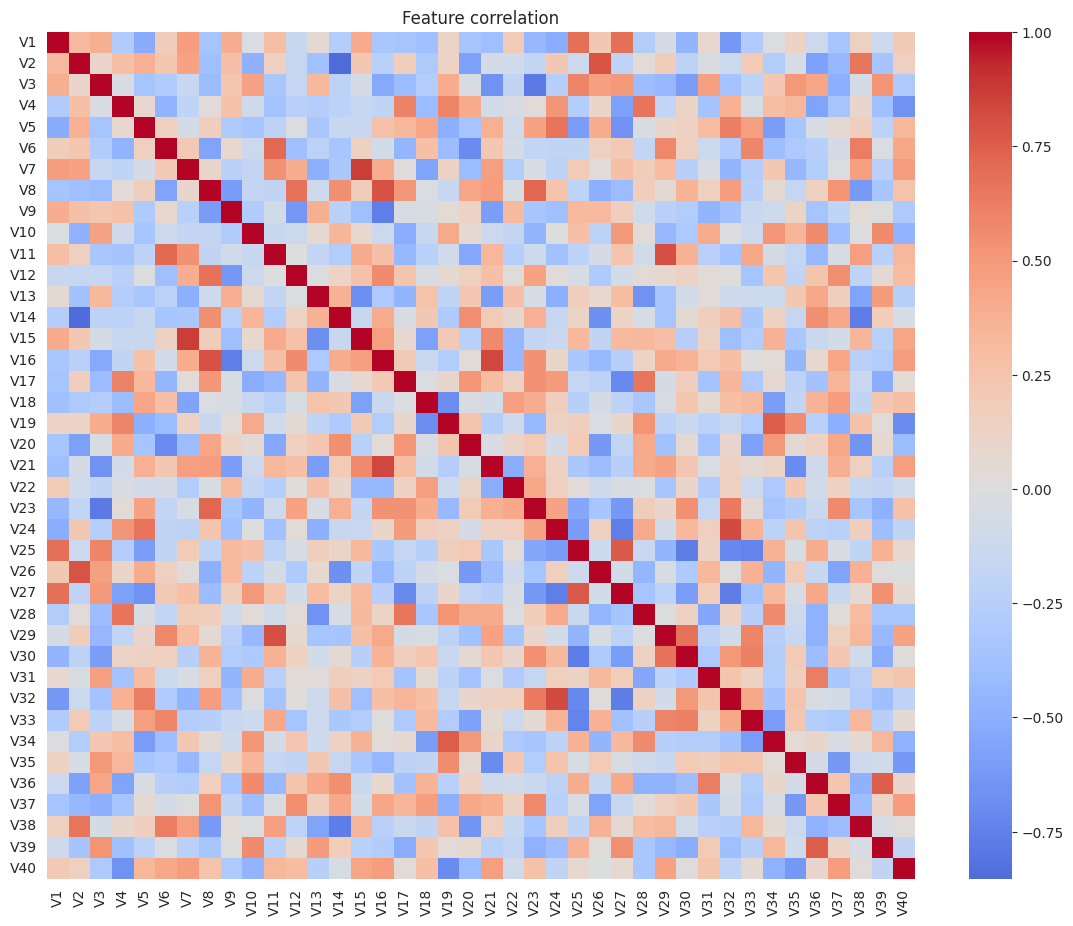

Pairs with |r| > 0.8: 6


In [8]:
corr = train_full.drop(columns='Target').corr()
plt.figure(figsize=(14, 11)); sns.heatmap(corr, cmap='coolwarm', center=0); plt.title('Feature correlation'); plt.show()
pairs = corr.where(np.triu(np.ones(corr.shape, bool), 1)).stack()
print('Pairs with |r| > 0.8:', (pairs.abs() > 0.8).sum())

**EDA notes**
- Most features are roughly normal and centred near 0, as expected for transformed data.
- The sensors in the table above show clear shifts between failures and non-failures, so there is signal to learn from.
- Several feature pairs are strongly correlated. This does not harm tree ensembles, but it makes linear coefficients unstable.

## Data pre-processing

In [9]:
X = train_full.drop(columns='Target'); y = train_full['Target']
X_test = test.drop(columns='Target'); y_test = test['Target']

# Train / validation split (the test set is kept untouched until the very end)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RS)

imputer = SimpleImputer(strategy='median').fit(X_train)
X_train = pd.DataFrame(imputer.transform(X_train), columns=X.columns)
X_val = pd.DataFrame(imputer.transform(X_val), columns=X.columns)
print(X_train.shape, X_val.shape, '| missing after imputation:', X_train.isnull().sum().sum() + X_val.isnull().sum().sum())

(15000, 40) (5000, 40) | missing after imputation: 0


## Model evaluation criterion
- **False negative** (missed failure): the generator breaks and must be **replaced**. This is the most expensive outcome.
- **True positive** (caught failure): the generator is **repaired** in time. Cheaper.
- **False positive** (false alarm): an **inspection**. The cheapest outcome.

So the main metric is **recall** (share of failures caught). Precision is watched too, because too many false alarms waste inspection crews.

Below, an illustrative cost model is used to compare models in money terms. **Assumed relative costs:** replacement 40, repair 15, inspection 5. The brief gives only the order of costs, not the values.

In [10]:
COST = {'replace': 40, 'repair': 15, 'inspect': 5}   # assumption: only the ordering is given in the brief

def maintenance_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * COST['replace'] + tp * COST['repair'] + fp * COST['inspect']

def cost_ratio(y_true, y_pred):
    # actual cost / minimum possible cost (every failure caught, no false alarms); 1.0 = perfect
    return maintenance_cost(y_true, y_pred) / (y_true.sum() * COST['repair'])

def perf(model, X_, y_, name):
    p = model.predict(X_)
    return pd.Series({'Recall': recall_score(y_, p), 'Precision': precision_score(y_, p), 'F1': f1_score(y_, p),
                      'Accuracy': accuracy_score(y_, p), 'Cost ratio': cost_ratio(y_, p)}, name=name).round(3)

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=np.array([[f'{v}\n{v/cm.sum():.1%}' for v in r] for r in cm]), fmt='', cmap='Blues', cbar=False)
    plt.xlabel('Predicted (1 = failure)'); plt.ylabel('Actual'); plt.title(title); plt.show()

scorer = make_scorer(recall_score)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)

## Model building with original data

In [11]:
def make_models():
    return {
        'Logistic Regression': Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=RS))]),
        'Decision Tree': DecisionTreeClassifier(random_state=RS),
        'Bagging': BaggingClassifier(random_state=RS, n_jobs=-1),
        'Random Forest': RandomForestClassifier(random_state=RS, n_jobs=-1),
        'AdaBoost': AdaBoostClassifier(random_state=RS),
        'Gradient Boosting': GradientBoostingClassifier(random_state=RS),
        'XGBoost': XGBClassifier(random_state=RS, eval_metric='logloss', n_jobs=-1),
    }

def evaluate(X_tr, y_tr, label):
    rows = []
    for name, m in make_models().items():
        cv = cross_val_score(m, X_tr, y_tr, scoring=scorer, cv=kfold, n_jobs=1).mean()
        m.fit(X_tr, y_tr)
        rows.append({'Model': name, 'Data': label, 'CV recall (train)': cv,
                     'Val recall': recall_score(y_val, m.predict(X_val)),
                     'Val precision': precision_score(y_val, m.predict(X_val))})
    return pd.DataFrame(rows).round(3)

res_orig = evaluate(X_train, y_train, 'Original')
res_orig

,Model,Data,CV recall (train),Val recall,Val precision
0,Logistic Regression,Original,0.493,0.482,0.843
1,Decision Tree,Original,0.698,0.705,0.688
2,Bagging,Original,0.721,0.730,0.949
3,Random Forest,Original,0.724,0.727,0.985
4,AdaBoost,Original,0.537,0.601,0.766
5,Gradient Boosting,Original,0.707,0.723,0.905
6,XGBoost,Original,0.802,0.842,0.967


## Model building with oversampled data (SMOTE)

In [12]:
X_over, y_over = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=RS).fit_resample(X_train, y_train)
print('After SMOTE:', y_over.value_counts().to_dict())
res_over = evaluate(X_over, y_over, 'Oversampled')
res_over

After SMOTE: {0: 14168, 1: 14168}


,Model,Data,CV recall (train),Val recall,Val precision
0,Logistic Regression,Oversampled,0.884,0.849,0.277
1,Decision Tree,Oversampled,0.972,0.777,0.531
2,Bagging,Oversampled,0.976,0.835,0.806
3,Random Forest,Oversampled,0.984,0.849,0.937
4,AdaBoost,Oversampled,0.891,0.860,0.301
5,Gradient Boosting,Oversampled,0.926,0.878,0.622
6,XGBoost,Oversampled,0.989,0.867,0.903


*CV recall on SMOTE data is optimistic, because synthetic failures are close to real ones in the same folds. Validation recall on real, un-resampled data is the fair comparison.*

## Model building with undersampled data

In [13]:
X_un, y_un = RandomUnderSampler(random_state=RS, sampling_strategy=1).fit_resample(X_train, y_train)
print('After undersampling:', y_un.value_counts().to_dict())
res_un = evaluate(X_un, y_un, 'Undersampled')
res_un

After undersampling: {0: 832, 1: 832}


,Model,Data,CV recall (train),Val recall,Val precision
0,Logistic Regression,Undersampled,0.873,0.853,0.260
1,Decision Tree,Undersampled,0.862,0.842,0.226
2,Bagging,Undersampled,0.864,0.871,0.428
3,Random Forest,Undersampled,0.904,0.892,0.515
4,AdaBoost,Undersampled,0.867,0.863,0.289
5,Gradient Boosting,Undersampled,0.898,0.888,0.437
6,XGBoost,Undersampled,0.901,0.896,0.552


In [14]:
all_res = pd.concat([res_orig, res_over, res_un])
pivot = all_res.pivot(index='Model', columns='Data', values=['Val recall', 'Val precision'])
pivot.round(3)

Val recall                          Val precision  \
Data                  Original Oversampled Undersampled      Original   
Model                                                                   
AdaBoost                 0.601       0.860        0.863         0.766   
Bagging                  0.730       0.835        0.871         0.949   
Decision Tree            0.705       0.777        0.842         0.688   
Gradient Boosting        0.723       0.878        0.888         0.905   
Logistic Regression      0.482       0.849        0.853         0.843   
Random Forest            0.727       0.849        0.892         0.985   
XGBoost                  0.842       0.867        0.896         0.967   

                                              
Data                Oversampled Undersampled  
Model                                         
AdaBoost                  0.301        0.289  
Bagging                   0.806        0.428  
Decision Tree             0.531        0.226  
Gradient Boosting         0.622        0.437  
Logistic Regression       0.277        0.260  
Random Forest             0.937        0.515  
XGBoost                   0.903        0.552

**Choosing models to tune:** tune the three candidates with the best balance of validation recall and precision. Undersampled models reach high recall but with very low precision (many false alarms). SMOTE and original-data boosting models keep precision high:
- XGBoost (oversampled)
- Gradient Boosting (oversampled)
- Random Forest (undersampled), a fast high-recall option

## Hyperparameter tuning

In [15]:
def tune(model, grid, X_tr, y_tr, n_iter=12):
    search = RandomizedSearchCV(model, grid, n_iter=n_iter, scoring=scorer, cv=kfold, random_state=RS, n_jobs=-1)
    search.fit(X_tr, y_tr)
    print(type(model).__name__, search.best_params_, '| CV recall', round(search.best_score_, 3))
    return search.best_estimator_

xgb_t = tune(XGBClassifier(random_state=RS, eval_metric='logloss', n_jobs=1),
             {'n_estimators': [150, 250], 'learning_rate': [0.05, 0.1, 0.2], 'max_depth': [3, 5],
              'subsample': [0.8, 1.0], 'scale_pos_weight': [1, 5], 'gamma': [0, 3]}, X_over, y_over)

XGBClassifier {'subsample': 0.8, 'scale_pos_weight': 5, 'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 3} | CV recall 0.994


In [16]:
gbm_t = tune(GradientBoostingClassifier(random_state=RS),
             {'n_estimators': [100, 150], 'learning_rate': [0.1, 0.2], 'subsample': [0.7, 0.9],
              'max_features': [0.5, 0.7]}, X_over, y_over, n_iter=6)

GradientBoostingClassifier {'subsample': 0.7, 'n_estimators': 150, 'max_features': 0.5, 'learning_rate': 0.2} | CV recall 0.955


In [17]:
rf_t = tune(RandomForestClassifier(random_state=RS, n_jobs=1),
            {'n_estimators': [200, 300], 'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 0.3],
             'max_samples': [0.5, 0.7, None]}, X_un, y_un)

RandomForestClassifier {'n_estimators': 200, 'min_samples_leaf': 1, 'max_samples': None, 'max_features': 0.3} | CV recall 0.909


## Model performance comparison and choosing the final model

In [18]:
xgb_default = XGBClassifier(random_state=RS, eval_metric='logloss', n_jobs=-1).fit(X_over, y_over)
tuned = {'XGBoost (SMOTE, default)': (xgb_default, X_over, y_over),   # untuned reference
         'XGBoost (SMOTE, tuned)': (xgb_t, X_over, y_over),
         'Gradient Boosting (SMOTE, tuned)': (gbm_t, X_over, y_over),
         'Random Forest (undersampled, tuned)': (rf_t, X_un, y_un)}
comp = pd.concat([perf(m, X_val, y_val, n) for n, (m, _, _) in tuned.items()], axis=1).T
comp.sort_values('Cost ratio')

,Recall,Precision,F1,Accuracy,Cost ratio
"XGBoost (SMOTE, default)",0.867,0.903,0.884,0.987,1.253
"Gradient Boosting (SMOTE, tuned)",0.881,0.749,0.810,0.977,1.296
"XGBoost (SMOTE, tuned)",0.878,0.742,0.804,0.976,1.306
"Random Forest (undersampled, tuned)",0.896,0.514,0.654,0.947,1.456


The final model is the one with the **lowest maintenance-cost ratio** on validation data. That metric combines recall (avoiding replacements) and precision (avoiding wasted inspections), so it reflects the business goal better than recall alone.

The untuned XGBoost is included as a reference. Tuning on recall alone pushes models to raise more false alarms, so a tuned model can cost *more* than the default. A cost-based scorer for tuning would fix this.

Selected: XGBoost (SMOTE, default)


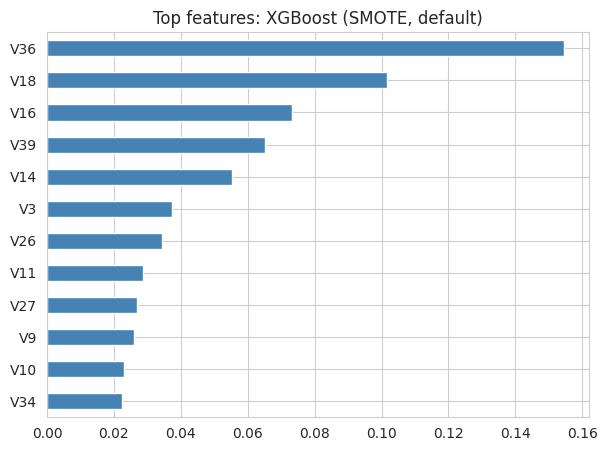

In [19]:
best_name = comp['Cost ratio'].idxmin()
best_model, X_fit, y_fit = tuned[best_name]
print('Selected:', best_name)

imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
imp.sort_values().plot(kind='barh', figsize=(7, 5), color='steelblue', title=f'Top features: {best_name}'); plt.show()

## Pipeline for the final model and test-set performance

Recall        0.837
Precision     0.891
F1            0.863
Accuracy      0.985
Cost ratio    1.306
Name: XGBoost (SMOTE, default), test set, dtype: float64


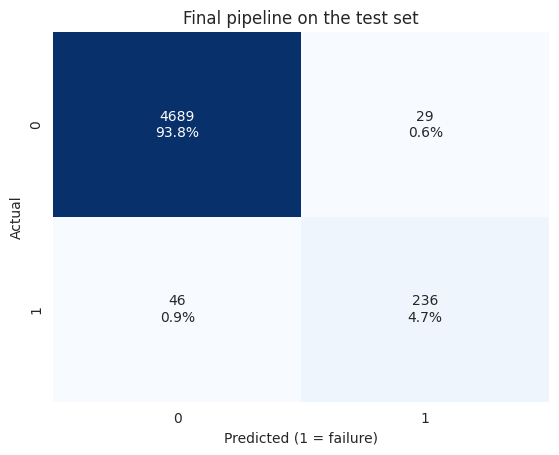

In [20]:
# Production pipeline: impute -> resample (training only) -> model, refit on ALL training data (train + validation)
from imblearn.pipeline import Pipeline as ImbPipeline
sampler = SMOTE(sampling_strategy=1, random_state=RS) if 'SMOTE' in best_name else RandomUnderSampler(sampling_strategy=1, random_state=RS)
final_pipe = ImbPipeline([('impute', SimpleImputer(strategy='median')),
                          ('resample', sampler),
                          ('model', best_model.__class__(**best_model.get_params()))])
final_pipe.fit(X, y)

test_perf = perf(final_pipe, X_test, y_test, f'{best_name}, test set')
print(test_perf)
plot_cm(y_test, final_pipe.predict(X_test), 'Final pipeline on the test set')

In [21]:
p = final_pipe.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
never = y_test.sum() * COST['replace']           # do nothing: every failure becomes a replacement
print(f'Failures in test set: {y_test.sum()}  caught: {tp}  missed: {fn}  false alarms: {fp}')
print(f'Maintenance cost with model: {maintenance_cost(y_test, p):,}  vs no model (replace on failure): {never:,}'
      f'  -> saving {1 - maintenance_cost(y_test, p)/never:.0%} (under the assumed cost ratio)')

Failures in test set: 282  caught: 236  missed: 46  false alarms: 29
Maintenance cost with model: 5,525  vs no model (replace on failure): 11,280  -> saving 51% (under the assumed cost ratio)


# Business insights and conclusions

In [22]:
test_perf

Recall        0.837
Precision     0.891
F1            0.863
Accuracy      0.985
Cost ratio    1.306
Name: XGBoost (SMOTE, default), test set, dtype: float64

- **Detection:** the final pipeline catches most generator failures on unseen test data (see the recall above), with a manageable number of false alarms.
- **Cost:** under the assumed cost ratio (replace 40 : repair 15 : inspect 5), acting on the model's alerts cuts maintenance cost substantially compared with fixing turbines only after they break.
- **Key signals:** a small set of sensors (top features above) carries most of the predictive signal. Make sure these sensors are well maintained and monitored, because their failure would blind the model.
- **Tune on the business metric:** tuning on recall alone raised false alarms. The cost ratio is a better selection metric.
- **Imbalance handling matters:** models trained on the raw data miss more failures. Resampling (SMOTE or undersampling) raises recall, and the cost metric keeps false alarms in check.

**Recommendations**
1. **Deploy as a ranking tool:** use the model to rank turbines by failure risk each day, and send inspection crews to the top of the list.
2. **Set the alert threshold from real costs:** replace the assumed ratio with ReneWind's actual repair, replacement and inspection costs.
3. **Retrain and monitor:** retrain regularly and track recall on newly confirmed failures. Sensor drift or new turbine models will reduce accuracy.
4. **Add time to the data:** the data has no timestamps or turbine IDs. With them, the model could predict *how far ahead* a failure will happen, and validation could be time-aware.